<figure>
<center>
<img src='https://www.economicas.uba.ar/wp-content/uploads/2020/08/cropped-logo_FCE.png' />
</figure>

# **Universidad de Buenos Aires**
## **Facultad de Ciencias Económicas**

### **Taller de Programación para el Análisis de Datos**

#### **Clase 7.2: Obtención de datos contenidos en una página web**

En esta clase veremos como extraer datos que se encuentran contenidos en una página web.

NOTA:



En esta clase veremos como extraer datos contenidos en páginas web.

Algunas consideraciones:

- Solo esposible hacer scrapping sobre aquellas páginas que así lo permiten. Por ejemplo, si en el código html se encuentra embebdida una app, no podrá escraparse.  

- No consultar una web reiteradamente ya que su IP puede ser bloqueada. Para evitar esto, ver los términos y condiciones de la web.

- Tener en cuenta que si una web cambia, su código puede dejar de funcionar

El lenguaje de programación de una página web es HTML (Hypertext Markup Language). Su estructura básica es como sigue:

    <!DOCTYPE html>  
    <html>  
        <head>
            <title>Título de la web</title>
        </head>
        <body>
            <h1> Encabezado de la web </h1>
            <p> Algún párrafo </p>
        <body>
    </html>

Para poder ver el código fuente de la página web, hacer clik derecho sobre la misma y seleccionar "Inspeccionar"


###**Librería**


Una de las librerías más utilizadas en Python para scrapear es [BeautifulSoup](https://www.crummy.com/software/BeautifulSoup/bs4/doc/)

In [ ]:
#se instala el módulo
!pip install beautifulsoup4

In [1]:
from bs4 import BeautifulSoup

In [2]:
import requests

###**Ejemplo 1**

Obtenemos un pdf para extraer una tabla de datos.

Este lo puede imprtar directamente al colab o descargarlo desde la web.



Comenzemos con una página conocida: [Yahoo Finance](https://finance.yahoo.com/)

Supongamso que nos interese extraer de https://finance.yahoo.com/markets/world-indices/ el valor de cotización de cierre del índice Merval

Lo primero es identificar cual es el symbol que le corresponde

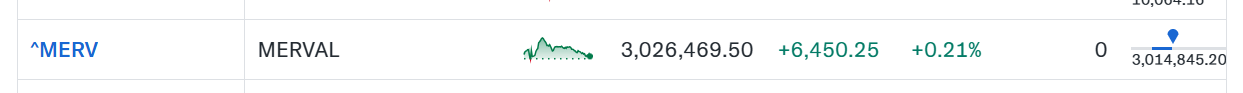

Luego posicionarse sobre esa fila y seleccionar inspeccionar

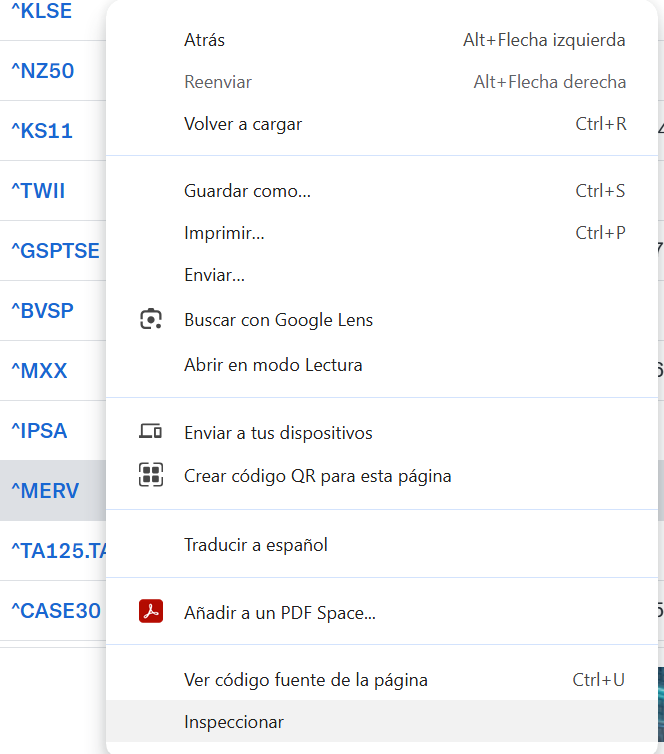

Al posicionarse sobre el código html vea que le marca a la izquierda en que parte del objeto web está

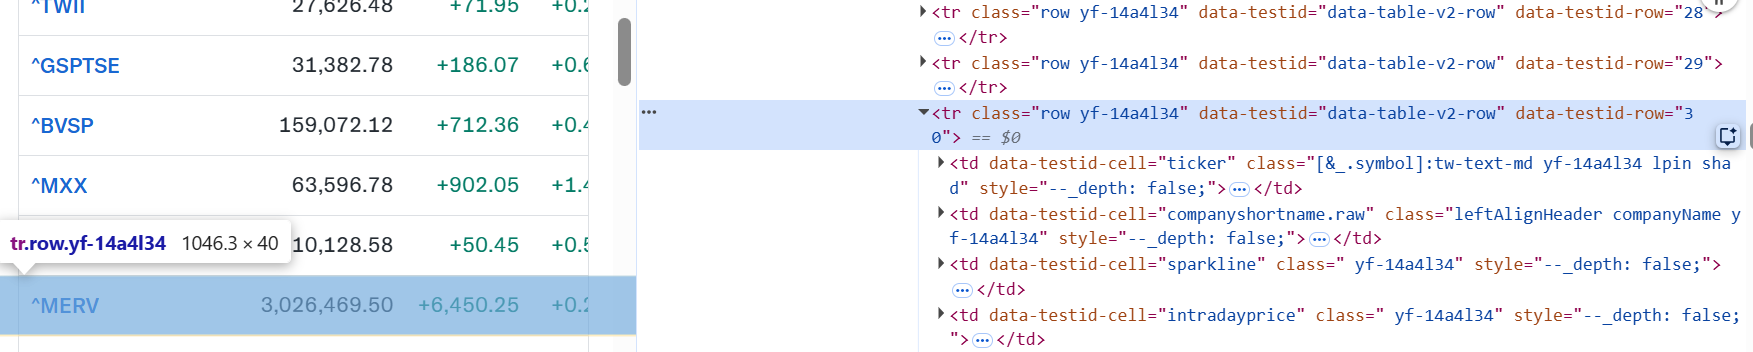

También observe que el atributo del html en este caso es $<tr$ y que posee hijos inferiores que son los atributos $<td$ siendo los de interés ya que contienen los datos (desplegando con al flechita negra puede observarlo)

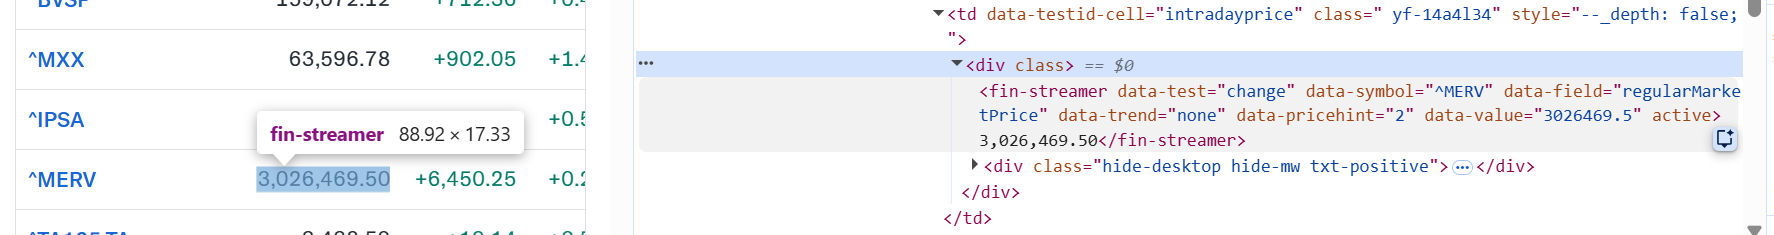




In [ ]:
url='https://finance.yahoo.com/world-indices'

header = {
	'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_11_2) AppleWebKit/601.3.9 (KHTML, like Gecko) Version/9.0.2 Safari/601.3.9'
}
response=requests.get(url,headers=header)


soup=BeautifulSoup(response.content, 'lxml')

ticker = "^MERV"
current = soup.select_one(f'fin-streamer[data-field="regularMarketPrice"][data-symbol="{ticker}"]')
price=current['data-value'] #en el código html ver el atributo que contiene el dato
price

import pandas as pd
data_MERV_Index= {'Nombre':'MERVAL', 'Precio_Cierre':[price]}
data_MERV_Index=pd.DataFrame(data_MERV_Index)
data_MERV_Index

,Nombre,Precio_Cierre
0,MERVAL,3026469.5


Si quiere extraer todos los ticker con su símbolo y precio, entonces

In [ ]:
from bs4 import BeautifulSoup
import requests

url='https://finance.yahoo.com/markets/world-indices/'

header = {
	'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_11_2) AppleWebKit/601.3.9 (KHTML, like Gecko) Version/9.0.2 Safari/601.3.9'
}
response=requests.get(url,headers=header)

soup=BeautifulSoup(response.content, 'lxml')

symbol=[]
price=[]

for item in soup.select(f'fin-streamer[data-field="regularMarketPrice"]'):
  symbol.append(item['data-symbol'])
  price.append(item['data-value'])

import pandas as pd
data= pd.DataFrame({'Symbol':symbol, 'Price':price})
data

,Symbol,Price
0,^GSPC,6849.09
1,^DJI,47716.42
2,^IXIC,23365.686
3,^NYA,21824.67
4,^XAX,7469.9707
...,...,...
62,BTC-USD,90761.29
63,ETH-USD,2994.6511
64,XRP-USD,2.2050867
65,BTC-CAD,126952.36


Recuerde que puede generar un csv y luego descargar los datos o sencillamente continuar trabajando con los mismos.

###**Ejemplo 2**

Supongamos que queremos alguno de los cuadros contenidos en https://www.cesla.com/indicadores-diarios-mercados-financieros-latinoamerica.php

In [3]:
#obtención del código html
page = requests.get("https://www.cesla.com/indicadores-diarios-mercados-financieros-latinoamerica.php",verify=False)
soup = BeautifulSoup(page.content, 'html.parser')
all_case= soup.find(class_="col-md-9")
print(all_case.prettify())

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'www.cesla.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


<div class="col-md-9">
 <img alt="Indicadores diarios de los mercados financieros de Latinoamérica" class="img-responsive" height="367" src="economia-latinoamericana-imagenes/indicadores-diarios-mercados-financieros-latinoamerica.jpg" style="float:left; margin-right:8px;" title="Indicadores diarios de los mercados financieros de Latinoamérica" width="320"/>
 <p class="recuadro-verde ocultar">
  <strong>
   DATOS DIARIOS: indicadores diarios de los mercados financieros de Latinoamérica
  </strong>
  .
  <br/>
  Cesla publica diariamente los datos de los principales indicadores de los mercados financieros de Latinoamérica, lo que permite un seguimiento actualizado de la situación presente y de las perspectivas de evolución de los mercados financieros del país. Las fuentes oficiales de información estadística consultadas han sido el Instituto de Estadística y el Banco Central del país.
 </p>
 <div class="clearfix">
 </div>
 <center>
  <h3>
   <b>
    TABLA DE  INDICADORES DIARIOS DE LOS M

In [4]:
#selección de datos de interés
soup.select('tr > td')

[<td colspan="5"><h4>Índices Bursátiles</h4></td>,
 <td colspan="3"> </td>,
 <td align="Right" colspan="3"><strong><font color="ffffff">Variación  hace...    </font></strong></td>,
 <td align="center" bgcolor="#f0fff0" width="25%"><strong></strong></td>,
 <td bgcolor="#f0fff0" width="25%"><strong>Nombre</strong></td>,
 <td align="center" bgcolor="#f0fff0" colspan="2"><strong>Último Dato</strong></td>,
 <td align="right" bgcolor="#f0fff0"><strong>3 meses</strong></td>,
 <td align="right" bgcolor="#f0fff0"><strong>1 año</strong></td>,
 <td bgcolor="#f0fff0">Argentina</td>,
 <td>MERVAL</td>,
 <td align="center" width="70">28-11-24</td>,
 <td align="right">0,55%</td>,
 <td align="right">49,64%</td>,
 <td align="right">141,66%</td>,
 <td height="5"></td>,
 <td bgcolor="#f0fff0">Brasil</td>,
 <td>IBOVESPA</td>,
 <td align="center" width="70">28-11-24</td>,
 <td align="right">-1,11%</td>,
 <td align="right">-1,09%</td>,
 <td align="right">-0,22%</td>,
 <td height="5"></td>,
 <td bgcolor="#f0f

In [5]:
#se extrae el texto contenido en cada td de interés

rows=soup.find_all('tr')

list_rows= []

for row in rows:
  row_td=row.find_all('td')
  str_cells=str(row_td)
  clean_text=BeautifulSoup(str_cells, "lxml").get_text()
  list_rows.append(clean_text)

In [6]:
#se crea un data frame con la información extraída
import pandas as pd
data=pd.DataFrame(list_rows)
data

,0
0,[Índices Bursátiles]
1,"[ , Variación hace... ]"
2,"[, Nombre, Último Dato, 3 meses, 1 año]"
3,"[Argentina, MERVAL, 28-11-24, 0,55%, 49,64%, 1..."
4,[]
...,...
97,[]
98,"[Uruguay, , 27-11-24, 91, 90, 85]"
99,[]
100,"[Venezuela, , 27-11-24, 22304, 17545, 18430]"


In [ ]:
#se convierte la infomarción extraída en columnas
data1=data[0].str.split(pat=", ", expand=True)

In [ ]:
#se observa
data1.head(20)

,0,1,2,3,4,5
0,[Índices Bursátiles],None,None,None,None,None
1,[,Variación hace... ],None,None,None,None
2,[,Nombre,Último Dato,3 meses,1 año],None
3,[Argentina,MERVAL,28-11-24,"0,55%","49,64%","141,66%]"
4,[],None,None,None,None,None
5,[Brasil,IBOVESPA,28-11-24,"-1,11%","-1,09%","-0,22%]"
6,[],None,None,None,None,None
7,[Chile,IGPA,28-11-24,"0,64%","1,45%","12,83%]"
8,[],None,None,None,None,None
9,[Colombia,COLCAP,28-11-24,"0,01%","3,63%","23,93%]"


In [ ]:
#se reduce la información a las columnas de interés
data_final=[data1[0], data1[3]]

In [ ]:
#se convierte a data frame
data_final=pd.DataFrame(data=data_final)

In [ ]:
#se observa
data_final.head(5)

,0,1,2,3,4,5,6,7,8,9,...,92,93,94,95,96,97,98,99,100,101
0,[Índices Bursátiles],[,[,[Argentina,[],[Brasil,[],[Chile,[],[Colombia,...,[México,[],[Perú,[],[Rep. Dominicana,[],[Uruguay,[],[Venezuela,[]
3,None,None,3 meses,"0,55%",None,"-1,11%",None,"0,64%",None,"0,01%",...,310,None,157,None,202,None,91,None,22304,None


In [ ]:
#se trasponen los datos del data frame
data_final=pd.DataFrame.transpose(data_final)

In [ ]:
#se observa
data_final

,0,3
0,[Índices Bursátiles],None
1,[,None
2,[,3 meses
3,[Argentina,"0,55%"
4,[],None
...,...,...
97,[],None
98,[Uruguay,91
99,[],None
100,[Venezuela,22304


In [ ]:
# por las dudas, se quitan seprador que puede poner el texto en dos filas dentro de la misma
data_final = data_final.replace('\n','', regex=True)
data_final

,0,3
0,[Índices Bursátiles],None
1,[,None
2,[,3 meses
3,[Argentina,"0,55%"
4,[],None
...,...,...
97,[],None
98,[Uruguay,91
99,[],None
100,[Venezuela,22304


In [ ]:
# se eliminan los símbolos
data_final=data_final.replace('\[','', regex=True)
data_final=data_final.replace('\]','', regex=True)
data_final

<>:2: SyntaxWarning: invalid escape sequence '\['
<>:3: SyntaxWarning: invalid escape sequence '\]'
<>:2: SyntaxWarning: invalid escape sequence '\['
<>:3: SyntaxWarning: invalid escape sequence '\]'
/tmp/ipython-input-2328612136.py:2: SyntaxWarning: invalid escape sequence '\['
  data_final=data_final.replace('\[','', regex=True)
/tmp/ipython-input-2328612136.py:3: SyntaxWarning: invalid escape sequence '\]'
  data_final=data_final.replace('\]','', regex=True)


,0,3
0,Índices Bursátiles,None
1,,None
2,,3 meses
3,Argentina,"0,55%"
4,,None
...,...,...
97,,None
98,Uruguay,91
99,,None
100,Venezuela,22304


In [ ]:
# se seleccionan las filas de interés, es decir, las correspondientes a los países de interés
data_final=data_final.iloc[[80,82,84,86,88,90,94,98,100],:]
data_final

,0,3
80,Argentina,757
82,Bolivia,2013
84,Brasil,205
86,Chile,122
88,Colombia,321
90,Ecuador,1289
94,Perú,157
98,Uruguay,91
100,Venezuela,22304


In [ ]:
#se reemplazan normbres de columnas
data_final = data_final.rename(columns={0:'PAIS', 3:'RIESGO_P'})
data_final

,PAIS,RIESGO_P
80,Argentina,757
82,Bolivia,2013
84,Brasil,205
86,Chile,122
88,Colombia,321
90,Ecuador,1289
94,Perú,157
98,Uruguay,91
100,Venezuela,22304


In [ ]:
#se resetea el indice
data_final=data_final.reset_index(0, drop=True)
data_final

,PAIS,RIESGO_P
0,Argentina,757
1,Bolivia,2013
2,Brasil,205
3,Chile,122
4,Colombia,321
5,Ecuador,1289
6,Perú,157
7,Uruguay,91
8,Venezuela,22304


Recuerde que puede generar un csv y luego descargar los datos o sencillamente continuar trabajando con los mismos.